<a href="https://colab.research.google.com/github/ruch-22/Data-Science-Lab-PS--II--Lab-/blob/main/cloneRegionDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install opencv-python-headless pdf2image Pillow numpy matplotlib -q
!apt-get install -y poppler-utils -q

Reading package lists...
Building dependency tree...
Reading state information...
poppler-utils is already the newest version (22.02.0-2ubuntu0.12).
0 upgraded, 0 newly installed, 0 to remove and 6 not upgraded.


In [ ]:
from PIL import Image, ImageChops, ImageEnhance
import matplotlib.pyplot as plt
import numpy as np
import cv2
from pdf2image import convert_from_path
import os

In [ ]:
def ela_image(path, quality=90):
    original = Image.open(path).convert('RGB')

    # Save compressed version
    temp_path = "temp_ela.jpg"
    original.save(temp_path, 'JPEG', quality=quality)

    compressed = Image.open(temp_path)

    # Difference
    diff = ImageChops.difference(original, compressed)

    # Enhance difference
    extrema = diff.getextrema()
    max_diff = max([ex[1] for ex in extrema])
    scale = 255.0 / max_diff if max_diff != 0 else 1
    diff = ImageEnhance.Brightness(diff).enhance(scale)

    return original, diff


# --------------------------------------------------
# Detect tampered regions and draw boxes
# --------------------------------------------------
def highlight_tampering(ela_img, original_img):
    ela_np = np.array(ela_img)
    gray = cv2.cvtColor(ela_np, cv2.COLOR_BGR2GRAY)

    # Threshold to get tampered regions
    _, thresh = cv2.threshold(gray, 30, 255, cv2.THRESH_BINARY)

    # Morphology to clean noise
    kernel = np.ones((5,5), np.uint8)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)

    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    img = np.array(original_img)

    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        if w*h > 500:  # ignore very small noise
            cv2.rectangle(img, (x,y), (x+w,y+h), (255,0,0), 2)

    return img

Processing Page 1


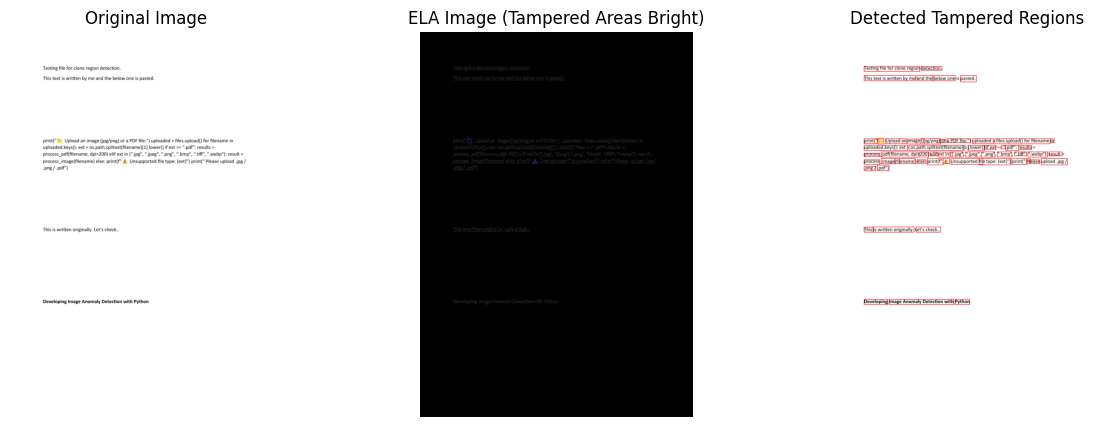

In [ ]:
def process_image(path):
    orig, ela = ela_image(path)
    result = highlight_tampering(ela, orig)

    plt.figure(figsize=(15,5))

    plt.subplot(1,3,1)
    plt.imshow(orig)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(ela)
    plt.title("ELA Image (Tampered Areas Bright)")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(result)
    plt.title("Detected Tampered Regions")
    plt.axis("off")

    plt.show()


# --------------------------------------------------
# Process PDF
# --------------------------------------------------
def process_pdf(path):
    pages = convert_from_path(path, dpi=200)

    for i, page in enumerate(pages):
        print(f"Processing Page {i+1}")
        temp_img = f"page_{i}.jpg"
        page.save(temp_img, "JPEG")
        process_image(temp_img)


# --------------------------------------------------
# Run
# --------------------------------------------------
for filename in uploaded.keys():
    ext = os.path.splitext(filename)[1].lower()

    if ext == ".pdf":
        process_pdf(filename)
    else:
        process_image(filename)